# setup

In [1]:

import numpy as np
import pandas as pd
import scipy
import math
import os.path as path
import re
import sys, types
import string
import yaml
import pickle

from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import logsumexp

import remodnav
import pymovements as pm
from I2MC import I2MC

from PIL import ImageFont
import matplotlib.font_manager as fm
from matplotlib import font_manager

import eyekit
from eyekit import TextBlock
from eyekit.fixation import Fixation, FixationSequence
import eyekit.vis as vis

In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
from src.cleaning import time_correction, cleaning, get_trial_chunks
from src.conversion import gaze_conversion
from src.visualization import plot_events, plot_gaze_across_time, plot_chunk_classification, plot_fixation_distribution, plot_main_sequence, plot_gazepath_eyekit, plot_accuracy_precision
from src.fixations import fixation_detection, fixation_merge_clean, saccade_clean, sort_fixation, mark_truncation
from src.text_processing import find_placement
from src.inspection import plot_scanpath_interactive
from src.eyekit_helper import create_text_block, create_aoi_boxes, create_seq
from src.fixation_cross import compute_accuracy_precision, summarize_acc_prec
from src.measures import fixation_measures

from subject_info import SUBJECT_INFO
import config
from manual_coding import fix_truncation

In [8]:
# load the data
datapath = '../data/raw'
plotpath = '../plots'
FONT_PATH = '/Users/qianyueli/Documents/fonts/droid-sans-mono/DroidSansMono.ttf'
SUBJECT = 5
LIST= SUBJECT_INFO[f'subj{SUBJECT}']['list']
EXCLUSION = SUBJECT_INFO[f'subj{SUBJECT}']['exclude']  #NOTE: lets deal with this later
events_data = pd.read_csv(path.join(datapath, f'subject-{SUBJECT}.csv'), sep=',', header=0)
et_data = pd.read_csv(path.join(datapath, f'subject-{SUBJECT}.tsv'), sep='\t', header=0)

RES = config.RESOLUTION
SCREEN_SIZE = config.SCREEN_SIZE
SMPL_RATE = config.SMPL_RATE
DIST = config.DISTANCE

FONT_SIZE = config.FONT_SIZE
FONT_FAM = config.FONT_FAM
MARGIN = config.MARGIN
WORD_SPACE = config.WORD_SPACE
LINE_SPACE = config.LINE_SPACE
CROSS_SIZE = config.CROSS_SIZE
TEXT_START = config.TEXT_START
CROSS_POS = config.CROSS_POS

# Preprocessing

In [9]:
events_data = events_data[events_data['list'] == LIST].reset_index(drop=True)
print(events_data)
events_data.to_csv(F'../data/preprocessed/events_subject-{SUBJECT}.csv', index=False)

                  AN Code                          RN        acc   accuracy  \
0    <AN>Frauen</AN>   C6       <RN>Expert*innen</RN>  undefined  undefined   
1    <AN>Männer</AN>   C3      <RN>Aktivistinnen</RN>  undefined  undefined   
2    <AN>Frauen</AN>   C6    <RN>Einwohner*innen</RN>  undefined  undefined   
3    <AN>Männer</AN>   C5       <RN>Expert*innen</RN>  undefined  undefined   
4    <AN>Frauen</AN>   C2     <RN>Krankenpfleger</RN>  undefined  undefined   
5    <AN>Frauen</AN>   C2           <RN>Experten</RN>  undefined  undefined   
6    <AN>Frauen</AN>   C6      <RN>Pfleger*innen</RN>  undefined  undefined   
7    <AN>Männer</AN>   C3     <RN>Ingenieurinnen</RN>  undefined  undefined   
8    <AN>Frauen</AN>   C2        <RN>Unternehmer</RN>  undefined  undefined   
9    <AN>Männer</AN>   C1         <RN>Ingenieure</RN>  undefined  undefined   
10   <AN>Männer</AN>   C1           <RN>Dozenten</RN>  undefined  undefined   
11   <AN>Männer</AN>   C3  <RN>Arbeitnehmerinnen</RN

In [10]:
et_data = time_correction(et_data)
et_data.head()

,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,LPUPILV,REYEX,REYEY,REYEZ,RPUPILD,RPUPILV,CX,CY,CS,USER
0,0,0.00000,702154736688,0.51495,0.48218,3801.42603,0.10693,1566,1,0.50134,...,1,0.02628,0.04104,0.62035,0.00377,1,1.39102,0.40833,0,NaN
1,1,0.00683,702154803799,0.51493,0.48180,3801.42603,0.11377,1566,1,0.51528,...,1,0.02628,0.04104,0.62035,0.00380,1,1.39102,0.40833,0,NaN
2,2,0.01294,702154866438,0.51492,0.48170,3801.42603,0.11987,1566,1,0.51634,...,0,0.02646,0.04117,0.62230,0.00363,1,1.39102,0.40833,0,START_TRIAL
3,3,0.02002,702154936849,0.51538,0.48151,3801.42603,0.12695,1566,1,0.52301,...,0,0.02646,0.04117,0.62230,0.00368,1,1.39102,0.40833,0,NaN
4,4,0.02661,702155001179,0.51485,0.48216,3801.42603,0.13354,1566,1,0.50514,...,0,0.02646,0.04117,0.62230,0.00369,1,1.39102,0.40833,0,NaN


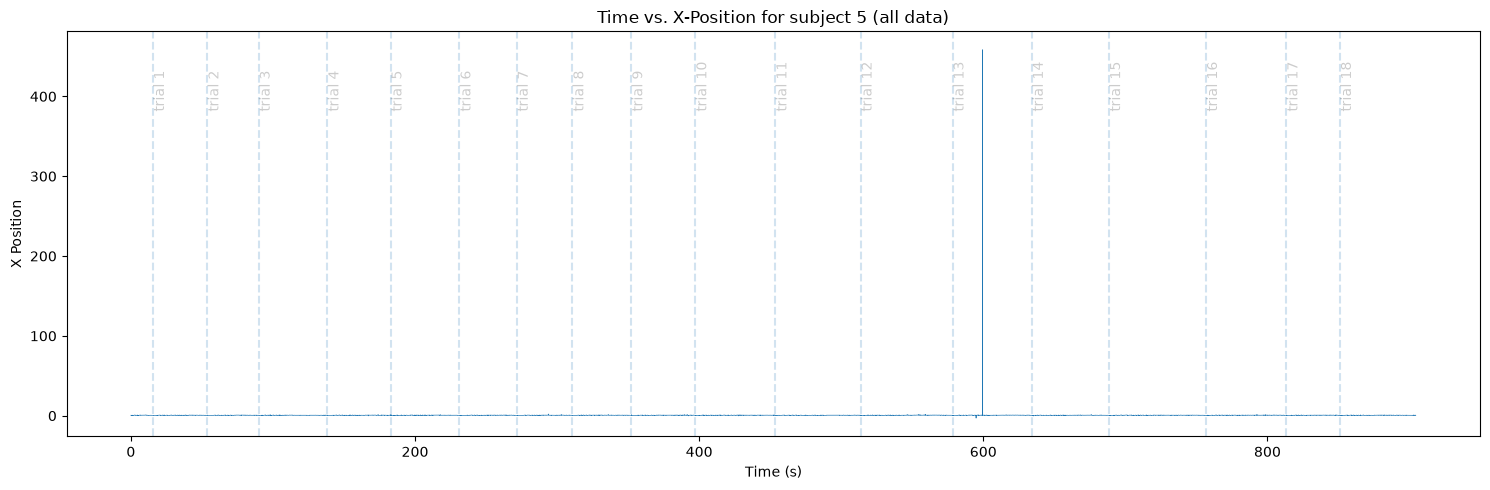

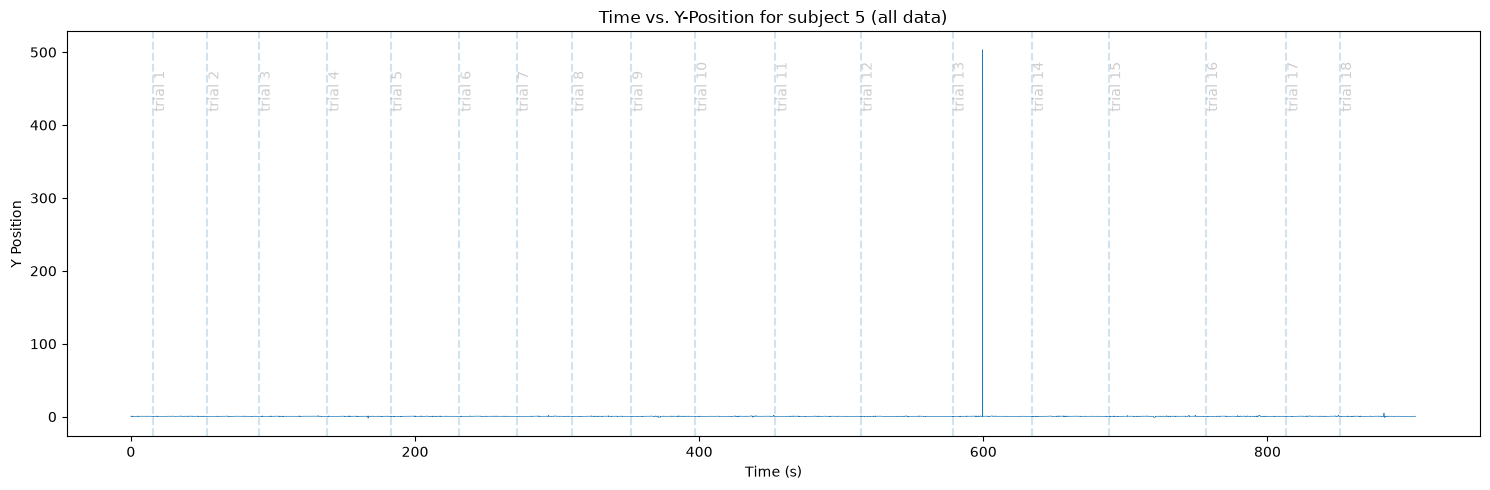

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Time vs. Y-Position for subject 5 (all data)'}, xlabel='Time (s)', ylabel='Y Position'>)

In [11]:
plot_gaze_across_time(et_data, axis="X", subject=SUBJECT, bar=True, note="(all data)")
plot_gaze_across_time(et_data, axis="Y", subject=SUBJECT, bar=True, note="(all data)")

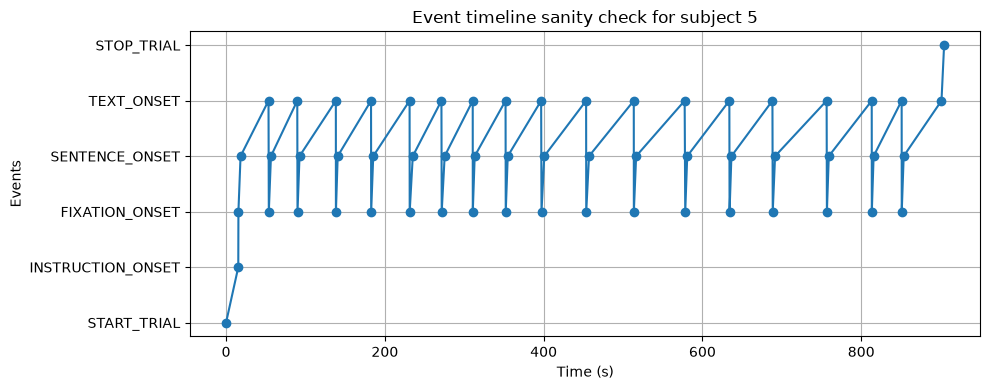

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Event timeline sanity check for subject 5'}, xlabel='Time (s)', ylabel='Events'>)

In [12]:
plot_events(et_data, subject=SUBJECT)

## exclude invalid data

In [13]:
et_data = cleaning(et_data)

The percentage of invalid data is 12.49%


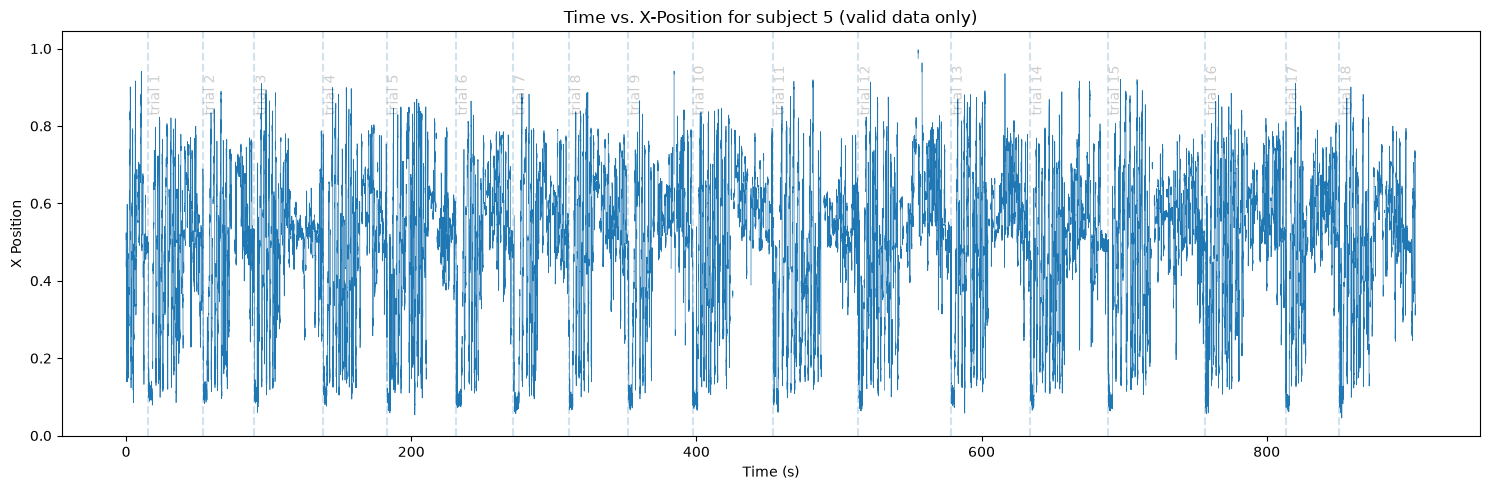

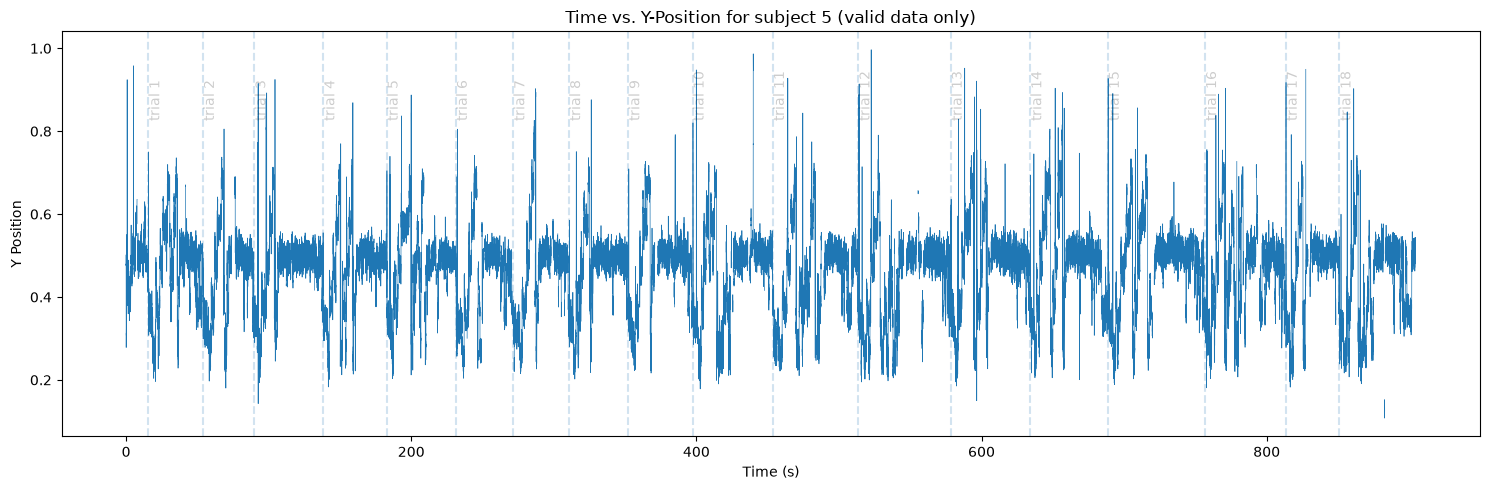

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'Time vs. Y-Position for subject 5 (valid data only)'}, xlabel='Time (s)', ylabel='Y Position'>)

In [14]:
plot_gaze_across_time(et_data, subject=SUBJECT, axis="X", bar=True, note="(valid data only)")
plot_gaze_across_time(et_data, subject=SUBJECT, axis="Y", bar=True, note="(valid data only)")

## gaze unit conversion

In [15]:
et_data = gaze_conversion(et_data, res=RES, dist=DIST, screen_size=SCREEN_SIZE)
et_data.head()

,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,CX,CY,CS,USER,X_px,Y_px,X_px_center,Y_px_center,X_deg,Y_deg
0,0,0.00000,702154736688,0.51495,0.48218,3801.42603,0.10693,1566,1,0.50134,...,1.39102,0.40833,0,NaN,972.4032,515.3652,12.4032,-24.6348,0.368213,-0.746861
1,1,0.00683,702154803799,0.51493,0.48180,3801.42603,0.11377,1566,1,0.51528,...,1.39102,0.40833,0,NaN,988.0320,513.4320,28.0320,-26.5680,0.832138,-0.805463
2,2,0.01294,702154866438,0.51492,0.48170,3801.42603,0.11987,1566,1,0.51634,...,1.39102,0.40833,0,START_TRIAL,988.5504,518.3244,28.5504,-21.6756,0.847524,-0.657154
3,3,0.02002,702154936849,0.51538,0.48151,3801.42603,0.12695,1566,1,0.52301,...,1.39102,0.40833,0,NaN,1006.0992,516.0240,46.0992,-23.9760,1.368304,-0.726890
4,4,0.02661,702155001179,0.51485,0.48216,3801.42603,0.13354,1566,1,0.50514,...,1.39102,0.40833,0,NaN,968.3328,534.8160,8.3328,-5.1840,0.247377,-0.157173


# Fixation Detection
- remember to calculate the percentage, add more plots etc.

## I-DT

In [16]:
method = 'I-DT'
threshold = config.FIX_CRITERIA['detection'][method]
segments_idt, classes_idt = fixation_detection(et_data, method=method, res=RES, dist=DIST, freq=SMPL_RATE, screen_size=SCREEN_SIZE, threshold=threshold)
et_data['segments_idt'] = segments_idt
et_data['classes_idt'] = classes_idt


/opt/homebrew/Caskroom/miniconda/base/envs/eyetrack/lib/python3.12/site-packages/cateyes/utils.py:365: UserWarning: 

Irregular sampling rate detected. This can lead to impaired performance with this classifier. Consider resampling your data to a fixed sampling rate. Setting sampling rate to average sample difference.
  warnings.warn(WARN_SFREQ)


In [17]:
et_data = fixation_merge_clean(et_data, cols=('classes_idt', 'segments_idt'), freq=SMPL_RATE, criteria=config.FIX_CRITERIA['cleaning']['fix_deg_dur'])
et_data = saccade_clean(et_data, cols=('classes_idt_clean', 'segments_idt_clean'), min_samples=config.FIX_CRITERIA['cleaning']['sacc_min'])

Total Valid Fixations Found: 3137


In [18]:
print("Classes unique values:", et_data['classes_idt'].value_counts())

Classes unique values: classes_idt
Fixation    88253
Saccade     46760
Name: count, dtype: int64


In [19]:
print("Classes unique values:", et_data['classes_idt_clean'].value_counts())

Classes unique values: classes_idt_clean
Fixation    84171
Saccade     50674
None          168
Name: count, dtype: int64


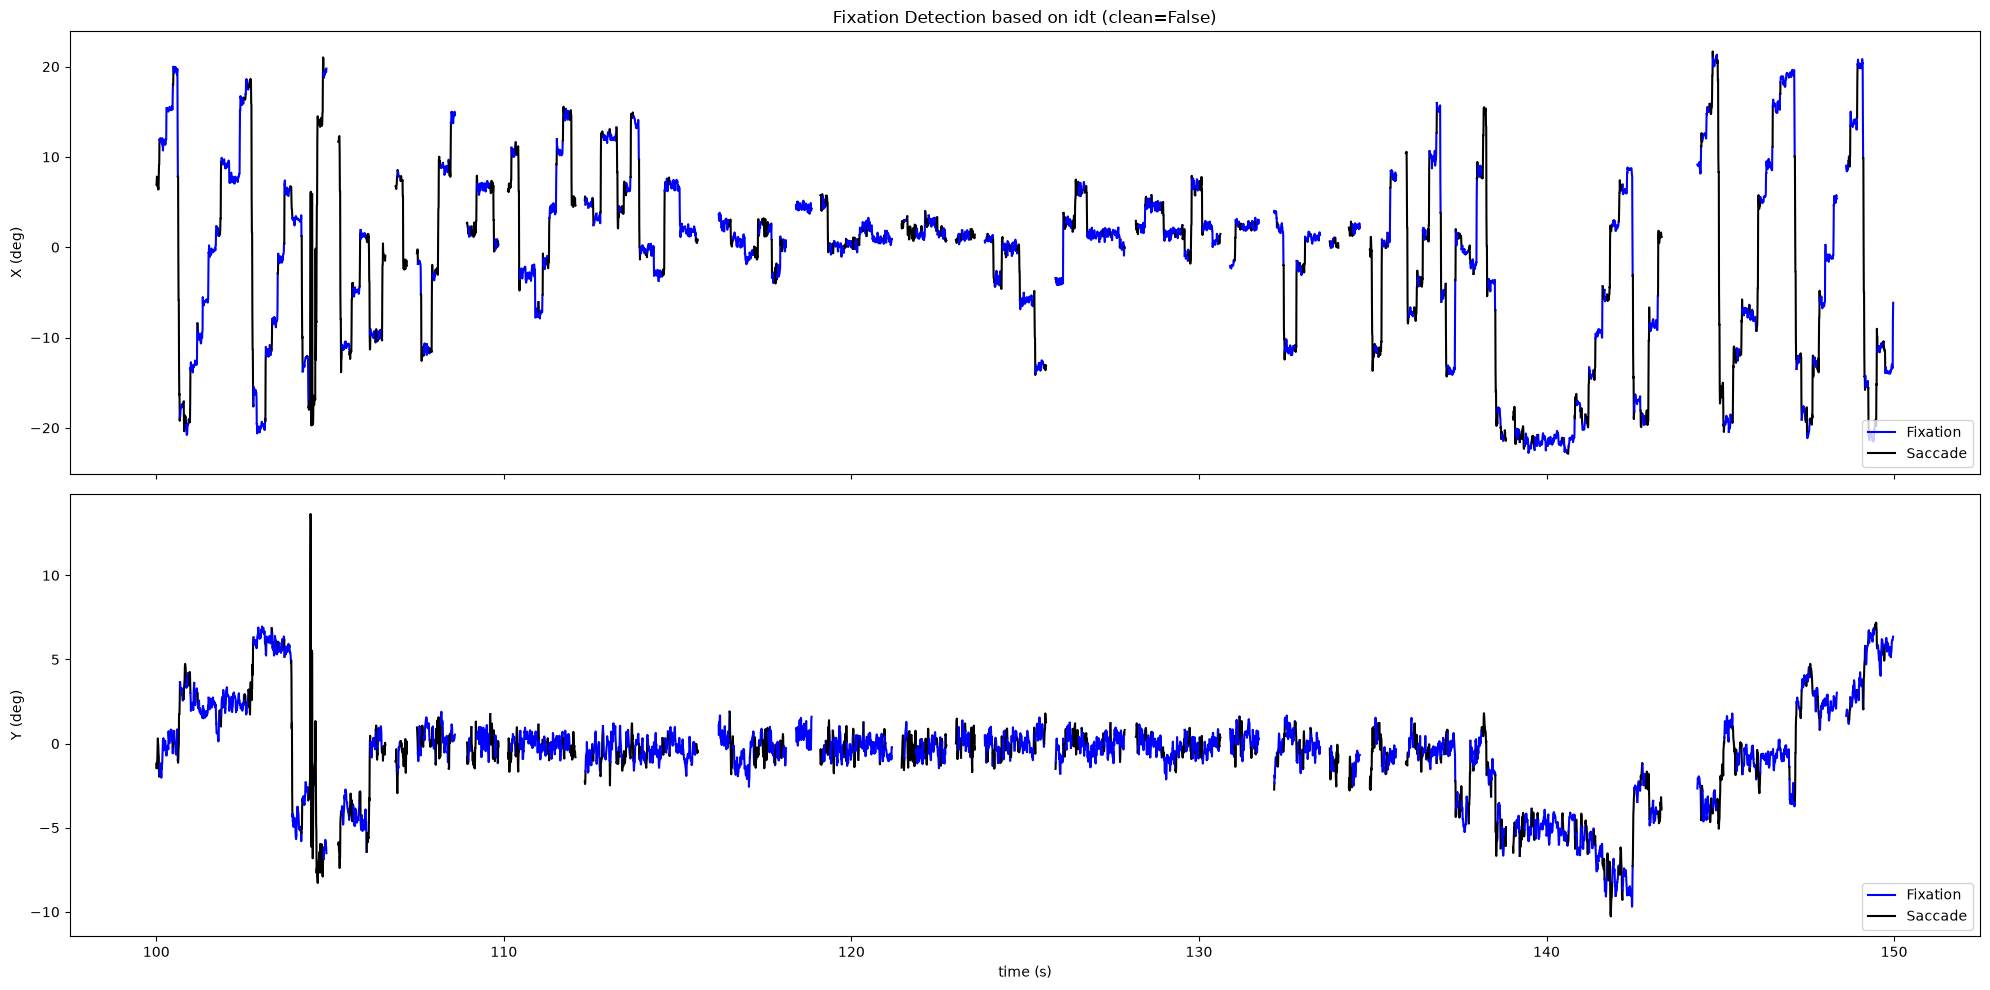

(<Figure size 2000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Fixation Detection based on idt (clean=False)'}, ylabel='X (deg)'>,
  <Axes: xlabel='time (s)', ylabel='Y (deg)'>))

In [20]:
plot_chunk_classification(et_data, window=(100, 150), class_method='idt', clean=False)

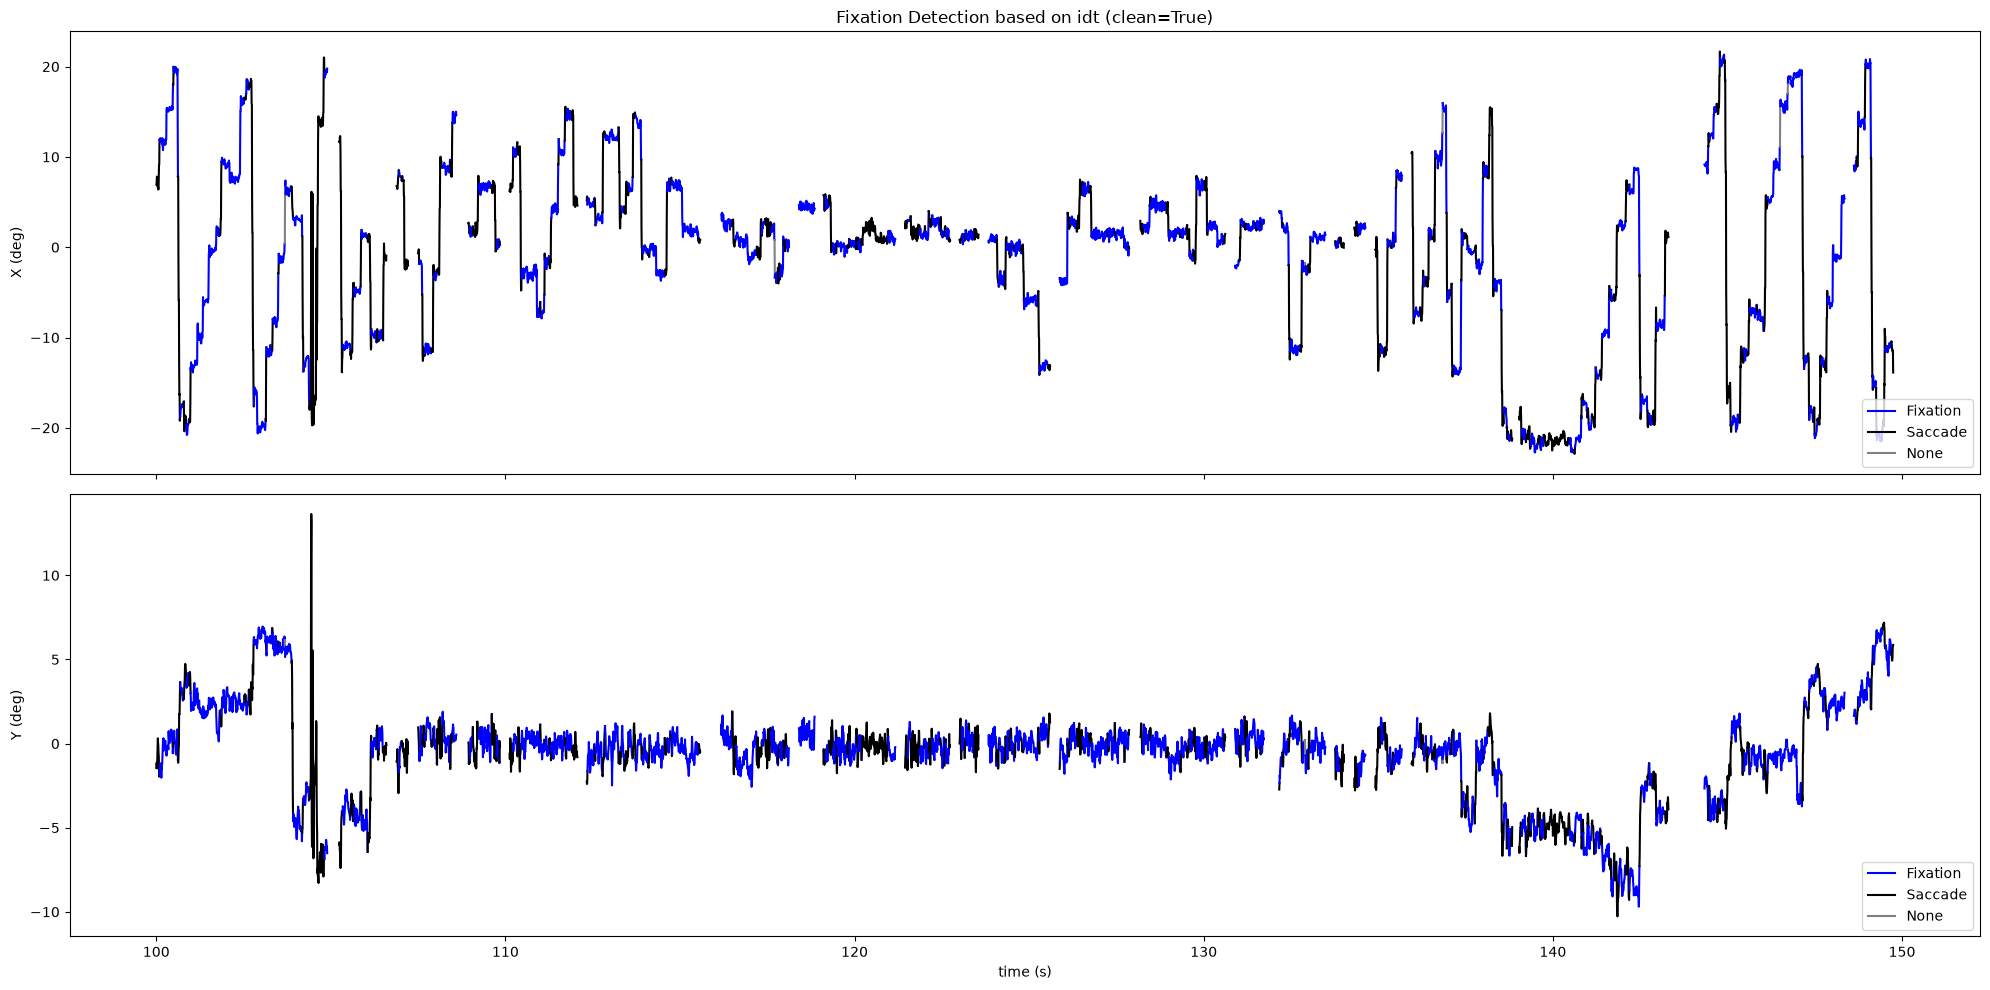

(<Figure size 2000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Fixation Detection based on idt (clean=True)'}, ylabel='X (deg)'>,
  <Axes: xlabel='time (s)', ylabel='Y (deg)'>))

In [21]:
plot_chunk_classification(et_data, window=(100, 150), class_method='idt', clean=True)

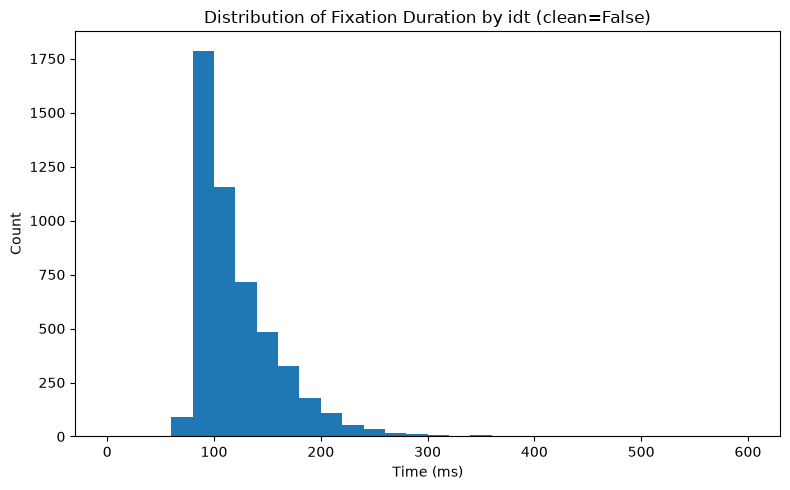

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Fixation Duration by idt (clean=False)'}, xlabel='Time (ms)', ylabel='Count'>)

In [22]:
plot_fixation_distribution(et_data, freq=SMPL_RATE, class_method='idt', clean=False)

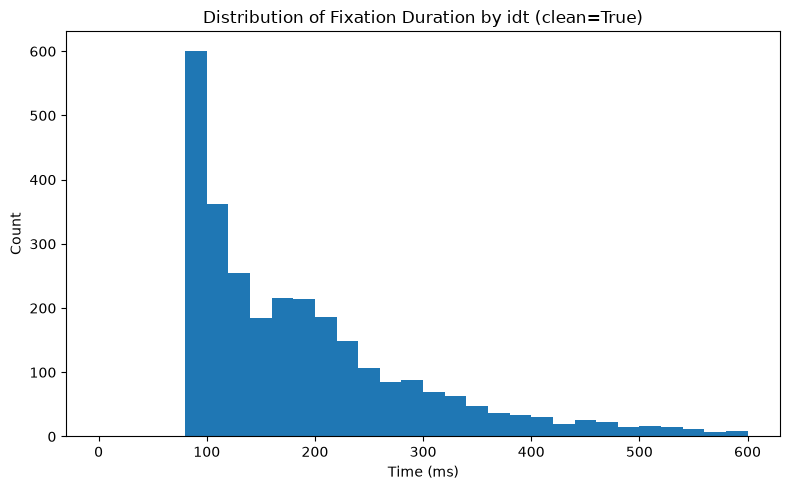

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Fixation Duration by idt (clean=True)'}, xlabel='Time (ms)', ylabel='Count'>)

In [23]:
plot_fixation_distribution(et_data, freq=SMPL_RATE, class_method='idt')

Total Saccades Detected: 3201


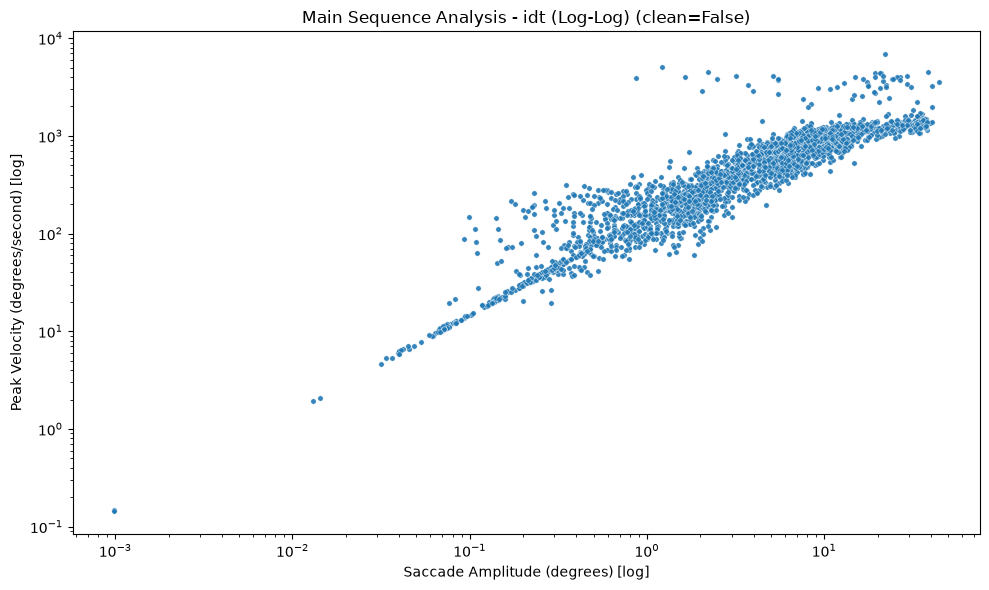

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Main Sequence Analysis - idt (Log-Log) (clean=False)'}, xlabel='Saccade Amplitude (degrees) [log]', ylabel='Peak Velocity (degrees/second) [log]'>,
       Amplitude  PeakVelocity
 0     10.742213    441.654229
 1      0.239147     36.289397
 2     12.261949    610.133302
 3      2.623172    398.053443
 4      3.545420    519.609745
 ...         ...           ...
 2914   0.133428     19.535550
 2915   3.312512    319.891308
 2916        NaN           NaN
 2917  11.102488    920.324393
 2918  13.431803   1220.080339
 
 [2919 rows x 2 columns])

In [24]:
plot_main_sequence(et_data, class_method='idt', clean=False)

Total Saccades Detected: 2732


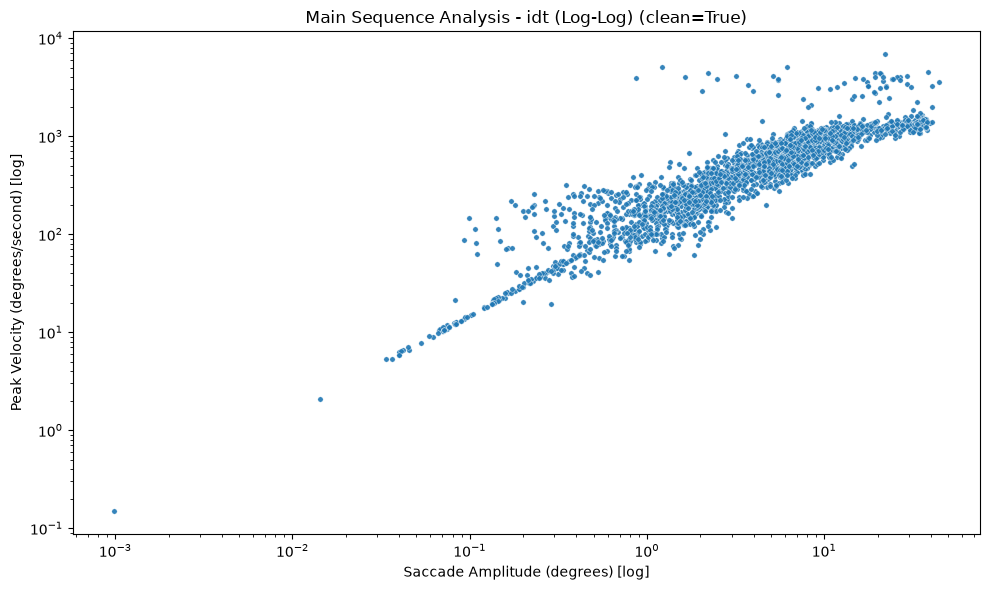

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Main Sequence Analysis - idt (Log-Log) (clean=True)'}, xlabel='Saccade Amplitude (degrees) [log]', ylabel='Peak Velocity (degrees/second) [log]'>,
       Amplitude  PeakVelocity
 0      7.514101    441.654229
 1      0.239147     36.289397
 2     12.261949    610.133302
 3      2.623172    398.053443
 4      3.545420    519.609745
 ...         ...           ...
 2727   0.133428     19.535550
 2728   3.312512    319.891308
 2729        NaN           NaN
 2730  11.102488    920.324393
 2731  13.431803   1220.080339
 
 [2732 rows x 2 columns])

In [25]:
plot_main_sequence(et_data, class_method='idt', clean=True)

## I2MC

In [26]:
method = 'I2MC'
threshold = config.FIX_CRITERIA['detection'][method]
segments_idt, classes_idt = fixation_detection(et_data, method=method, res=RES, dist=DIST, freq=SMPL_RATE, screen_size=SCREEN_SIZE, threshold=threshold)
et_data['segments_i2mc'] = segments_idt
et_data['classes_i2mc'] = classes_idt

I2MC: Searching for valid interpolation windows
I2MC: Replace interpolation windows with Steffen interpolation
I2MC: 2-Means clustering started for averaged signal
I2MC: Determining fixations based on clustering weight mean for averaged signal and separate eyes + 2.00*std


In [27]:
et_data = fixation_merge_clean(et_data, cols=('classes_i2mc', 'segments_i2mc'), freq=SMPL_RATE, criteria=config.FIX_CRITERIA['cleaning']['fix_deg_dur'])
et_data = saccade_clean(et_data, cols=('classes_i2mc_clean', 'segments_i2mc_clean'), min_samples=config.FIX_CRITERIA['cleaning']['sacc_min'])

Total Valid Fixations Found: 2795


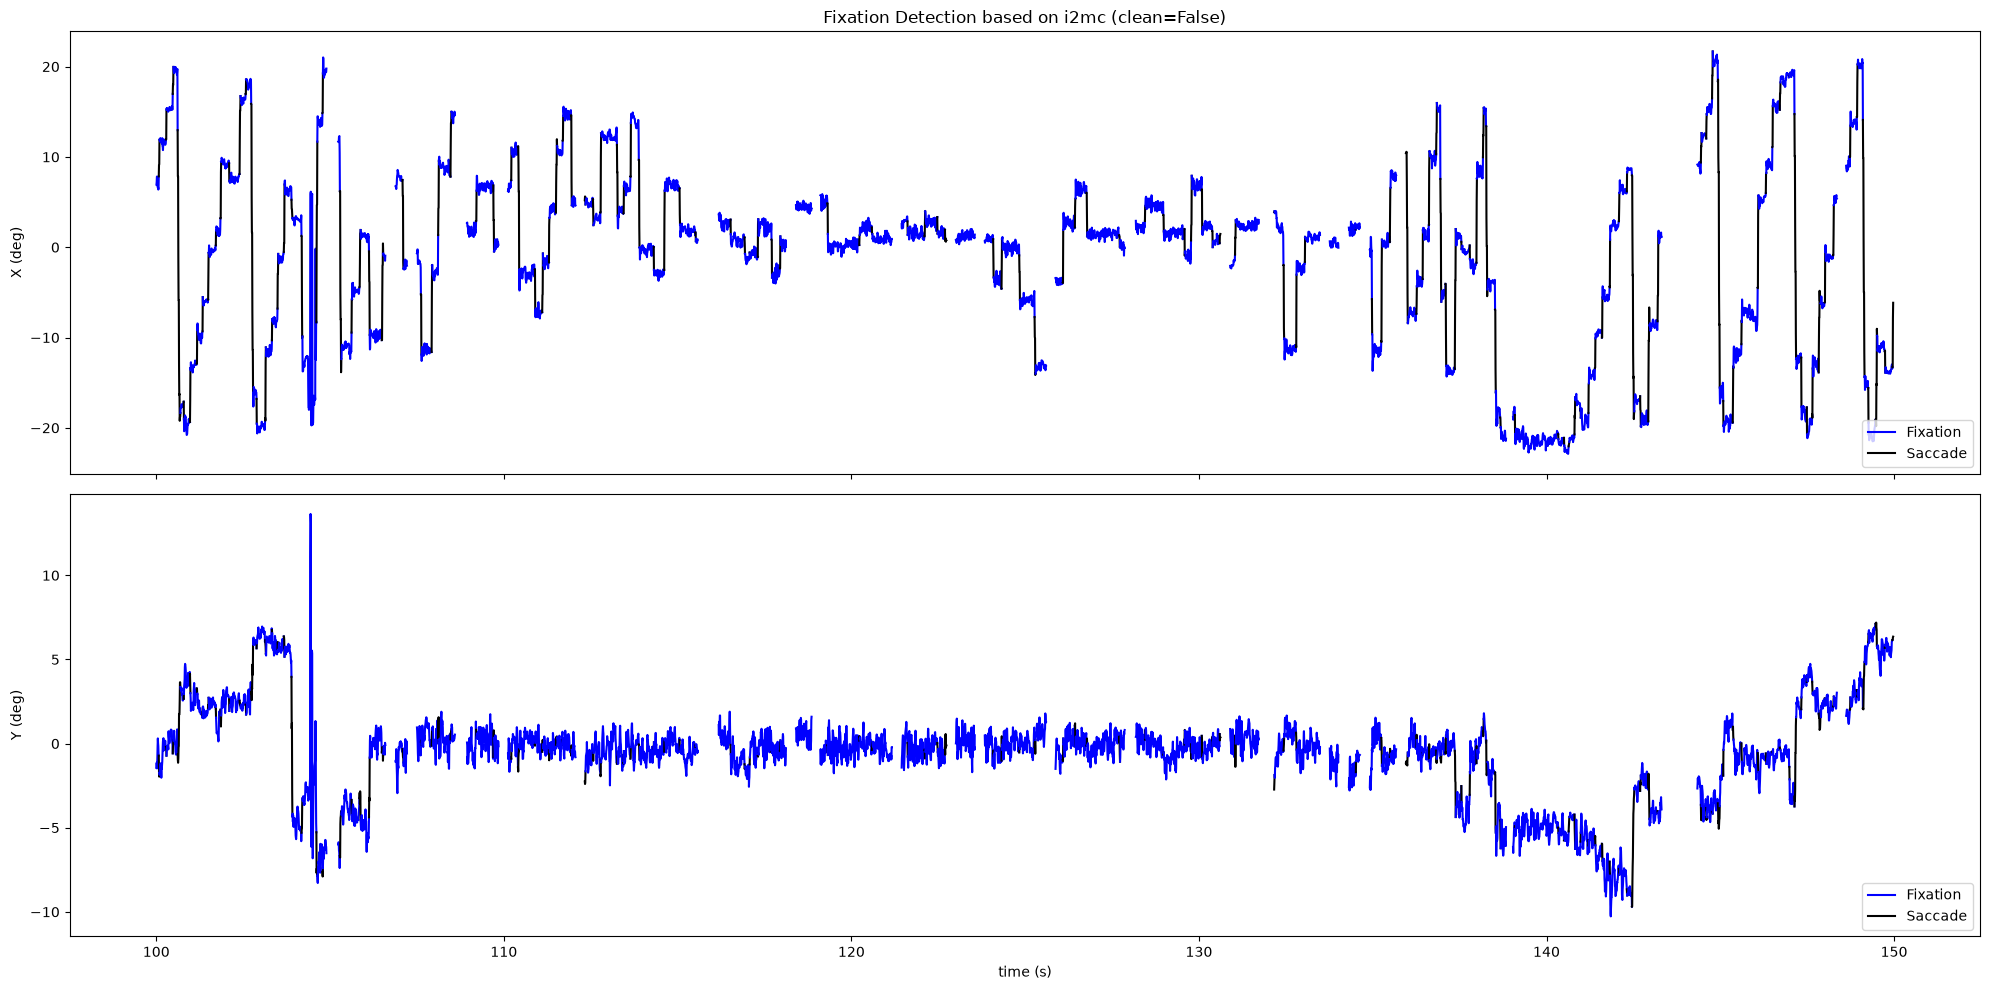

(<Figure size 2000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Fixation Detection based on i2mc (clean=False)'}, ylabel='X (deg)'>,
  <Axes: xlabel='time (s)', ylabel='Y (deg)'>))

In [28]:
plot_chunk_classification(et_data, window=(100, 150), class_method='i2mc', clean=False)

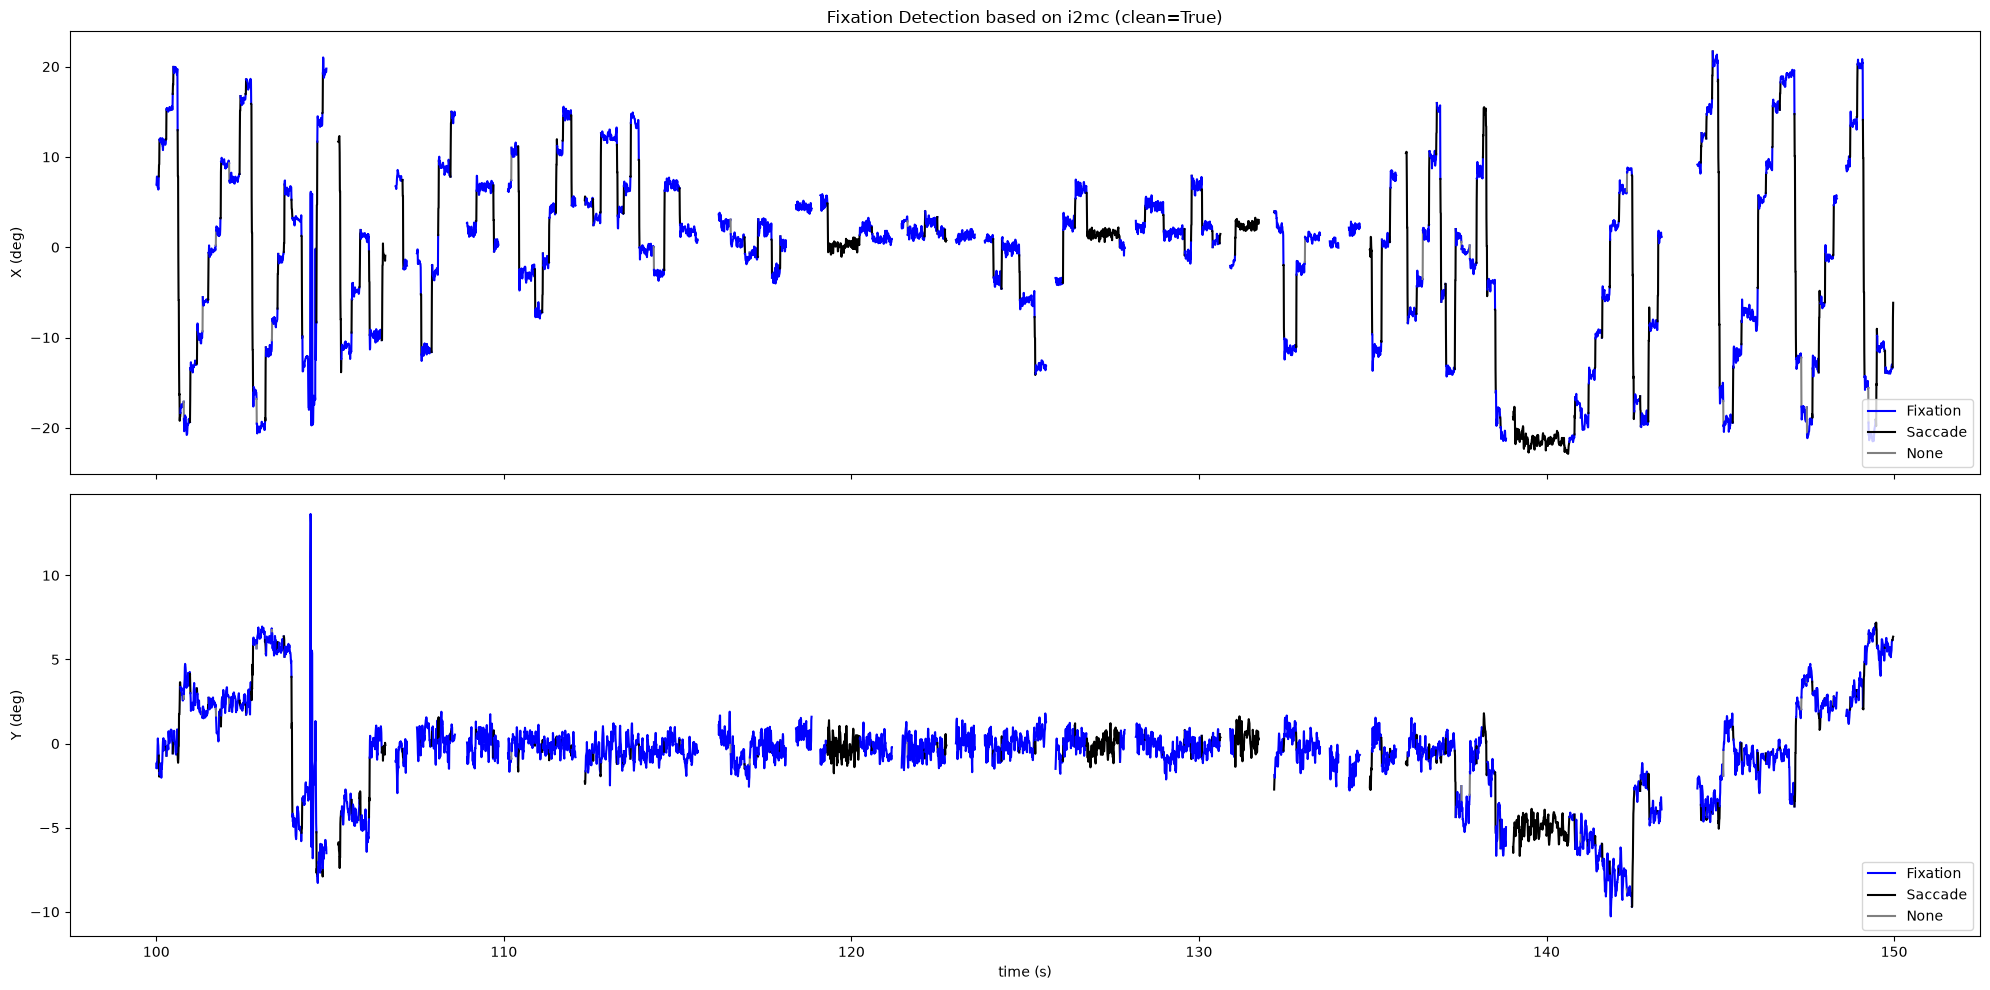

(<Figure size 2000x1000 with 2 Axes>,
 (<Axes: title={'center': 'Fixation Detection based on i2mc (clean=True)'}, ylabel='X (deg)'>,
  <Axes: xlabel='time (s)', ylabel='Y (deg)'>))

In [29]:
plot_chunk_classification(et_data, window=(100, 150), class_method='i2mc')

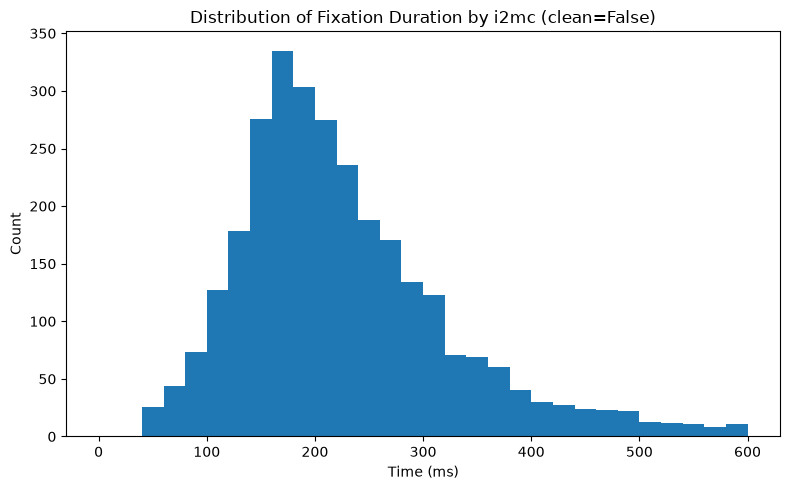

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Fixation Duration by i2mc (clean=False)'}, xlabel='Time (ms)', ylabel='Count'>)

In [30]:
plot_fixation_distribution(et_data, freq=SMPL_RATE, class_method='i2mc', clean=False)

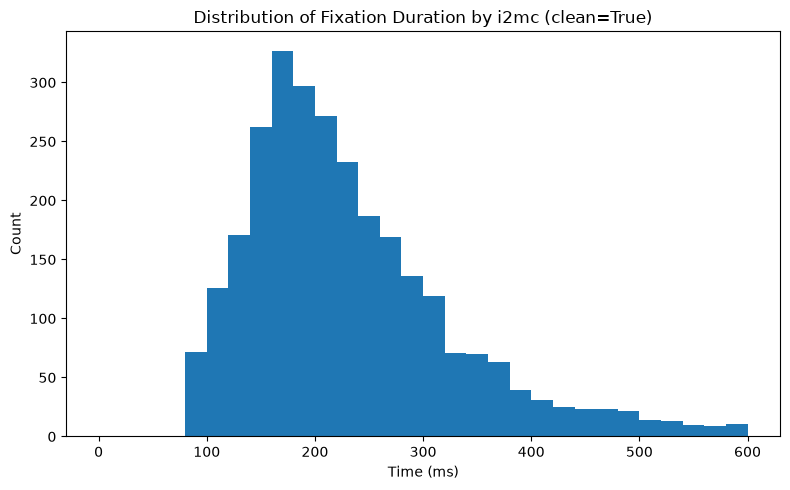

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Fixation Duration by i2mc (clean=True)'}, xlabel='Time (ms)', ylabel='Count'>)

In [31]:
plot_fixation_distribution(et_data, freq=SMPL_RATE, class_method='i2mc')

Total Saccades Detected: 2990


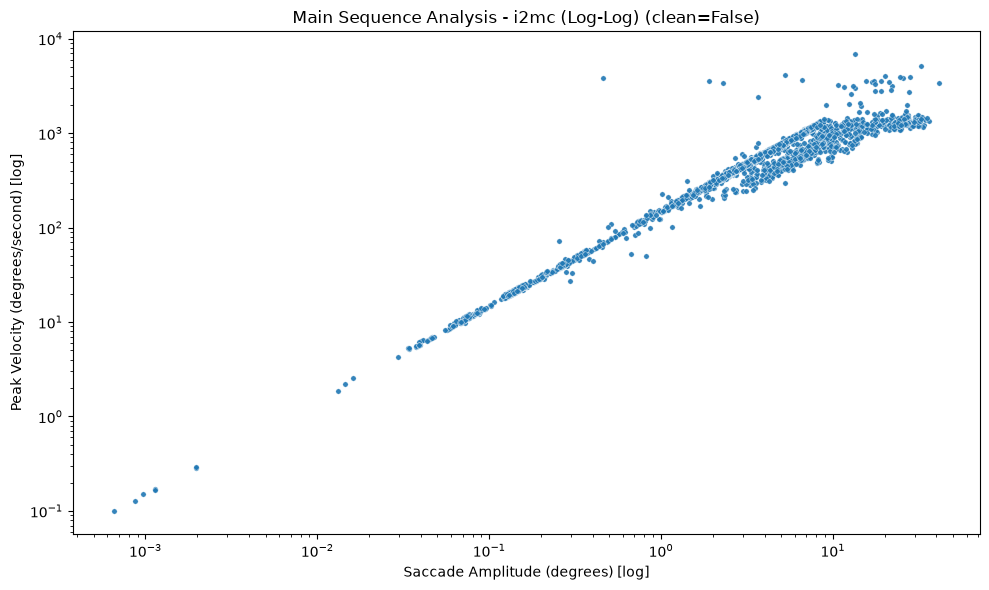

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Main Sequence Analysis - i2mc (Log-Log) (clean=False)'}, xlabel='Saccade Amplitude (degrees) [log]', ylabel='Peak Velocity (degrees/second) [log]'>,
       Amplitude  PeakVelocity
 0      3.556632    372.733167
 1      4.609813    682.785980
 2      2.641672    405.951733
 3      9.350451    884.059752
 4      4.363320    649.756919
 ...         ...           ...
 2628        NaN           NaN
 2629  15.758174   1259.767599
 2630   3.662430    531.700553
 2631   0.000000      0.000000
 2632   4.869218    761.403939
 
 [2633 rows x 2 columns])

In [32]:
plot_main_sequence(et_data, class_method='i2mc', clean=False)

Total Saccades Detected: 2510


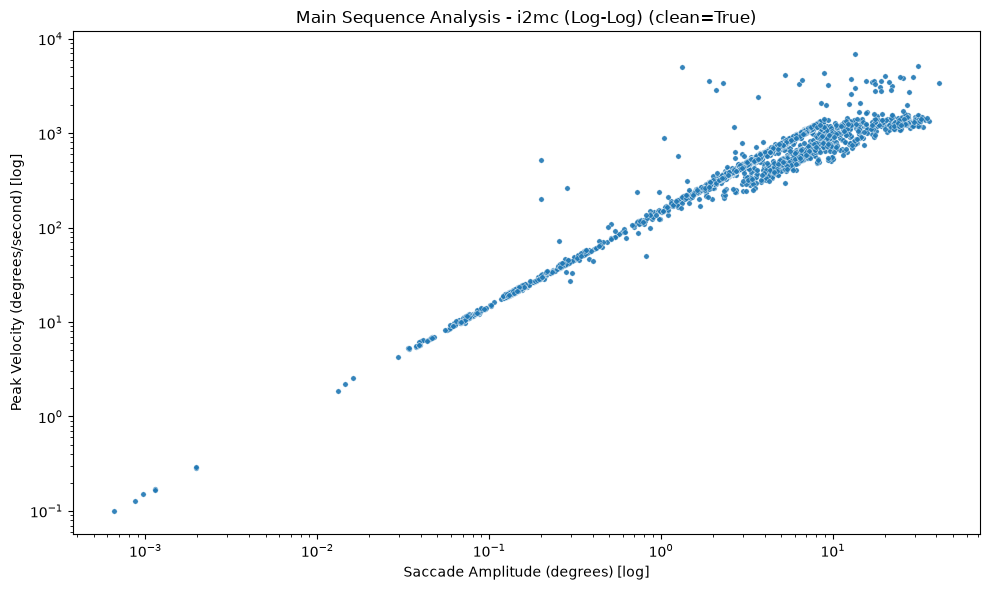

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Main Sequence Analysis - i2mc (Log-Log) (clean=True)'}, xlabel='Saccade Amplitude (degrees) [log]', ylabel='Peak Velocity (degrees/second) [log]'>,
       Amplitude  PeakVelocity
 0      3.556632    372.733167
 1      4.609813    682.785980
 2      2.641672    405.951733
 3      9.350451    884.059752
 4      4.363320    649.756919
 ...         ...           ...
 2505   0.203186     29.705559
 2506        NaN           NaN
 2507   3.662430    531.700553
 2508   0.000000      0.000000
 2509   4.869218    761.403939
 
 [2510 rows x 2 columns])

In [33]:
plot_main_sequence(et_data, class_method='i2mc')

# Segmentation

In [34]:
cross_data = get_trial_chunks(et_data, start_marker='FIXATION_ONSET', end_marker='SENTENCE_ONSET')
sentence_data = get_trial_chunks(et_data, start_marker='SENTENCE_ONSET', end_marker='TEXT_ONSET')

Starts: [2324, 8040, 13435, 20655, 27285, 34529, 40549, 46393, 52589, 59313, 67722, 76673, 86336, 94671, 102789, 112973, 121420, 127047]
Ends: [2725, 8442, 13813, 20992, 27672, 35106, 41103, 46750, 52966, 59833, 68242, 77104, 86711, 95018, 103228, 113330, 121756, 127412]
Starts: [2725, 8442, 13813, 20992, 27672, 35106, 41103, 46750, 52966, 59833, 68242, 77104, 86711, 95018, 103228, 113330, 121756, 127412]
Ends: [7982, 13390, 20643, 27260, 34509, 40496, 46381, 52552, 59245, 67697, 76661, 86227, 94631, 102732, 112922, 121403, 127030, 134521]


In [35]:
cross_data.head()

,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,Y_deg,segments_idt,classes_idt,classes_idt_clean,segments_idt_clean,segments_i2mc,classes_i2mc,classes_i2mc_clean,segments_i2mc_clean,SENTENCE_INDEX
0,2324,15.56689,702310403938,0.48956,0.44240,3816.84521,0.25464,1633,1,0.49888,...,-2.075096,179,Fixation,Fixation,110,129,Fixation,Fixation,122,0
1,2325,15.57349,702310470833,0.48950,0.44219,3816.84521,0.26123,1633,1,0.49686,...,-2.159462,179,Fixation,Fixation,110,129,Fixation,Fixation,122,0
2,2326,15.58032,702310538013,0.48940,0.44241,3816.84521,0.26807,1633,1,0.49368,...,-1.604390,179,Fixation,Fixation,110,129,Fixation,Fixation,122,0
3,2327,15.58691,702310605267,0.48930,0.44255,3816.84521,0.27466,1633,1,0.49368,...,-1.685857,179,Fixation,Fixation,110,129,Fixation,Fixation,122,0
4,2328,15.59350,702310671722,0.48925,0.44283,3816.84521,0.28125,1633,1,0.48191,...,-1.488886,179,Fixation,Fixation,110,129,Fixation,Fixation,122,0


In [36]:
fixations = sort_fixation(sentence_data, freq=SMPL_RATE)

# Accuracy & Precision

In [37]:
acc_prec = compute_accuracy_precision(cross_data, CROSS_POS, last_ms=100)

In [38]:
acc_prec.head()

,SENTENCE_INDEX,accuracy_px,precision_rms_px,precision_sd_px,n_samples,cross_x_px,cross_y_px
0,0,93.262996,11.659210,23.766693,15,-772.01664,-185.32224
1,1,78.527177,18.816344,31.458509,15,-768.60160,-203.77152
2,2,227.961723,301.583707,267.435905,15,-678.12352,-84.55608
3,3,85.420060,14.659610,11.421126,15,-799.61216,-185.71392
4,4,78.103737,23.712382,27.149648,15,-808.79232,-192.40560


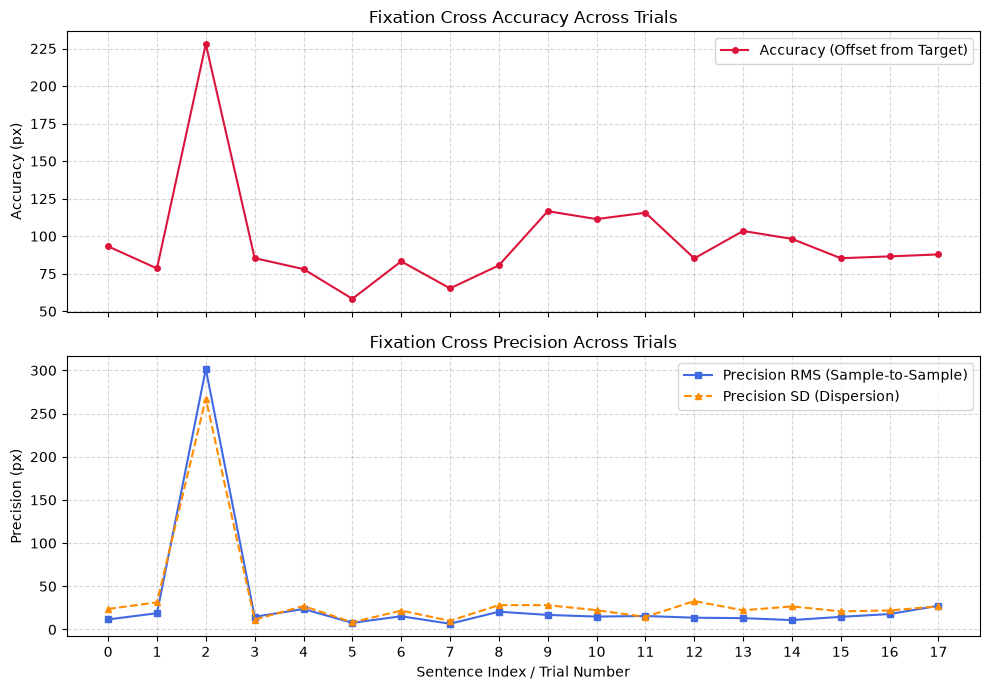

In [39]:
plot_accuracy_precision(acc_prec, CROSS_POS)

from here we stick with only one fixation method

# Scan Path

In [40]:
sentence_data.head()

,CNT,TIME,TIME_TICK,FPOGX,FPOGY,FPOGS,FPOGD,FPOGID,FPOGV,LPOGX,...,Y_deg,segments_idt,classes_idt,classes_idt_clean,segments_idt_clean,segments_i2mc,classes_i2mc,classes_i2mc_clean,segments_i2mc_clean,SENTENCE_INDEX
0,2725,18.25268,702337263912,0.10362,0.33351,3819.63184,0.13379,1643,0,0.12477,...,-5.053743,221,Fixation,Fixation,122,143,Fixation,Saccade,131,0
1,2726,18.25952,702337331124,0.10540,0.33688,3819.77246,0.02002,1644,1,0.12717,...,-4.997205,221,Fixation,Fixation,122,143,Fixation,Saccade,131,0
2,2727,18.26611,702337398025,0.10501,0.34067,3819.77246,0.02661,1644,1,0.12452,...,-4.710791,221,Fixation,Fixation,122,143,Fixation,Saccade,131,0
3,2728,18.27295,702337465265,0.10445,0.34143,3819.77246,0.03345,1644,1,0.12261,...,-5.053743,223,Fixation,Fixation,122,143,Fixation,Saccade,131,0
4,2729,18.27954,702337532413,0.10389,0.34173,3819.77246,0.04004,1644,1,0.12030,...,-5.110271,223,Fixation,Fixation,122,143,Fixation,Saccade,131,0


## Customized scan path for better inspection

In [41]:
fixations.head()

,Start,Duration,X_px_center,Y_px_center,X_px,Y_px,X_deg,Y_deg,Sentence_i
0,18715.09,167.306667,-374.744064,-218.175552,585.255936,321.824448,-10.988065,-6.585366,0
1,18895.51,308.416667,-128.783165,-268.262843,831.216835,271.737157,-3.817361,-8.079026,0
2,19230.71,241.046667,81.478400,-282.293700,1041.478400,257.706300,2.417396,-8.494043,0
3,19491.94,194.166667,274.447448,-267.048993,1234.447448,272.951007,8.093093,-8.042839,0
4,19713.13,274.496667,444.205580,-239.985483,1404.205580,300.014517,12.961455,-7.237163,0


>note: need to truncate the tail as it might contaminate every measure except for first pass measuring 

measures that are affected:
- regressions
- total fixations

measures that are not affected:
- go-past
- first pass fixation

In [42]:
#NOTE: comment out for truncation, put back later
fixations = mark_truncation(fixations, fix_truncation[f'subj{SUBJECT}'])

In [43]:
fixations.tail()

,Start,Duration,X_px_center,Y_px_center,X_px,Y_px,X_deg,Y_deg,Sentence_i,keep
2673,897209.23,154.126667,-336.761322,-3.348939,623.238678,536.651061,-9.897500,-0.101524,17,False
2674,897389.89,154.126667,290.348243,-11.571026,1250.348243,528.428974,8.554470,-0.350773,17,False
2675,897550.54,154.126667,527.595130,14.426452,1487.595130,554.426452,15.287854,0.437379,17,False
2676,897738.52,281.086667,-71.625143,-36.142714,888.374857,503.857286,-2.125252,-1.095569,17,False
2677,898032.96,274.726667,8.704156,-21.066322,968.704156,518.933678,0.258390,-0.638649,17,False


>note: the overlay does not map to how text is displayed in opensesame exactly. The starting position of each word matches, but bc the different font/rendering, the length of each word is slightly off, which lead the uneven spacing between each word unlike the uniform spacing in opensesame interface.

>NOTE: need check subj3 - sentence 16: bad misalignment

In [44]:
#%matplotlib widget

In [45]:
#plot_scanpath_interactive(event_data=events_data, fixation_data=fixations, subject=SUBJECT, sentence_i=17, res=RES, font_size=FONT_SIZE, font_path=FONT_PATH)

## eyekit

In [46]:
textblock_out_path = f'../data/eyekit/subj{SUBJECT}_textblock.pkl'
aoi_out_path = f'../data/eyekit/subj{SUBJECT}_aoi.pkl'
seq_out_path = f'../data/eyekit/subj{SUBJECT}_seq.pkl'
seq_corr_out_path = f'../data/eyekit/subj{SUBJECT}_seqcorr.pkl'
seq_stats_out_path = f'../data/eyekit/subj{SUBJECT}_seqstats.pkl'

In [47]:
eyekit_text_path = f'../data/splitted_sentences/splitted_sentences_SUBJ{SUBJECT}.csv'
eyekit_text = pd.read_csv(eyekit_text_path)
text_blocks = create_text_block(eyekit_text, TEXT_START, RES, FONT_SIZE, LINE_SPACE)
# with open(textblock_out_path, "wb") as f:
#     pickle.dump(text_blocks, f)

In [48]:
aoi = create_aoi_boxes(events_data, RES, FONT_SIZE)
with open(aoi_out_path, "wb") as f:
    pickle.dump(aoi, f)

In [49]:
seq = create_seq(fixations)
with open(seq_out_path, "wb") as f:
    pickle.dump(seq, f)

In [50]:
print(aoi)

{0: {'rn': (150.0, 484.0, 271.0, 53.0), 'an': (737.0, 601.0, 132.0, 53.0), 'spill': (869.0, 601.0, 132.0, 53.0), 'text_box': (150.0, 250.0, 1620.0, 507.0)}, 1: {'rn': (1221.0, 367.0, 297.0, 53.0), 'an': (759.0, 601.0, 135.0, 53.0), 'spill': (894.0, 601.0, 135.0, 53.0), 'text_box': (150.0, 250.0, 1620.0, 507.0)}, 2: {'rn': (150.0, 484.0, 340.0, 53.0), 'an': (781.0, 601.0, 132.0, 53.0), 'spill': (913.0, 601.0, 132.0, 53.0), 'text_box': (150.0, 250.0, 1620.0, 507.0)}, 3: {'rn': (150.0, 484.0, 271.0, 53.0), 'an': (651.0, 601.0, 135.0, 53.0), 'spill': (786.0, 601.0, 135.0, 53.0), 'text_box': (150.0, 250.0, 1620.0, 507.0)}, 4: {'rn': (1330.0, 367.0, 317.0, 53.0), 'an': (829.0, 601.0, 132.0, 53.0), 'spill': (961.0, 601.0, 132.0, 53.0), 'text_box': (150.0, 250.0, 1620.0, 507.0)}, 5: {'rn': (309.0, 484.0, 179.0, 53.0), 'an': (897.0, 601.0, 132.0, 53.0), 'spill': (1029.0, 601.0, 132.0, 53.0), 'text_box': (150.0, 250.0, 1620.0, 507.0)}, 6: {'rn': (150.0, 484.0, 294.0, 53.0), 'an': (738.0, 601.0, 

In [52]:
for i in range(18):
    path_gazepath = path.join(plotpath, f'gazepath/subj{SUBJECT}/gazepath_subj{SUBJECT}-trial{i}.png')
    plot_gazepath_eyekit(text_blocks[i], aoi[i], seq[i], RES, path_gazepath)

In [53]:
corr_method = ['chain', 'merge', 'cluster']  
seq_corr = {}
seq_stats = {}
for i in range(18):
    seq_corr_i = seq[i].copy()
    d, k = seq_corr_i.snap_to_lines(text_blocks[i], method=corr_method)
    path_gazepath_corr = path.join(plotpath, f'gazepath/subj{SUBJECT}/gazepath_subj{SUBJECT}-trial{i}({corr_method}).png')
    plot_gazepath_eyekit(text_blocks[i], aoi[i], seq_corr_i, RES, path_gazepath_corr)
    print(f'trial {i} - d: {d}, k: {k}.')

    seq_corr[i] = seq_corr_i
    seq_stats[i] = {'d': d, 'k': k}

with open(seq_corr_out_path, "wb") as f:
    pickle.dump(seq_corr, f)

with open(seq_stats_out_path, "wb") as f:
    pickle.dump(seq_stats, f)

trial 0 - d: 21.472972972972972, k: 0.9309307752138968.
trial 1 - d: 23.74025974025974, k: 0.7244620449448923.
trial 2 - d: 19.81132075471698, k: 0.7510354581270833.
trial 3 - d: 20.333333333333332, k: 0.9388671006347794.
trial 4 - d: 20.15740740740741, k: 0.9762978858299399.
trial 5 - d: 16.615384615384617, k: 0.9869626261950925.
trial 6 - d: 21.25, k: 0.9214184968768891.
trial 7 - d: 19.46031746031746, k: 0.7210430137756538.
trial 8 - d: 22.589285714285715, k: 0.8955595026642985.
trial 9 - d: 22.524271844660195, k: 0.8830020283975659.
trial 10 - d: 21.798387096774192, k: 0.937593200119296.
trial 11 - d: 24.95575221238938, k: 0.8595982605094219.
trial 12 - d: 21.119565217391305, k: 0.962823275862069.
trial 13 - d: 23.978021978021978, k: 0.697566061711903.
trial 14 - d: 21.70689655172414, k: 0.9638696816794371.
trial 15 - d: 24.51851851851852, k: 0.9061255040200882.
trial 16 - d: 22.903846153846153, k: 0.7715959004392389.
trial 17 - d: 20.645569620253166, k: 0.9428998217125236.


>NOTE: the drfit on the side is bigger, fixations on the edge are likely get misassigned no matter which correction method is used

In [54]:
# # testing
# corr_tests = ['chain', 'cluster', 'merge', 'regress', 'segment', 'slice', 'split', 'stretch', 'warp']
# for corr_test in corr_tests:
#     path_gazepath_corr_test = path.join(plotpath, f'gazepath/tests(subj1)/gazepath_subj{SUBJECT}-trial{0}({corr_test}).png')
#     seq_test = seq[0].copy()
#     d, k = seq_test.snap_to_lines(text_blocks[0], method=corr_test)
#     plot_gazepath_eyekit(text_blocks[0], aoi[0], seq_test, RES, path_gazepath_corr_test)

In [55]:
# eyekit.tools.align_to_screenshot(text_blocks[10], '../plots/subj1_trial11_screenshot.png')

In [56]:
# screenshot_path = "../plots/subj1_trial11_screenshot.png"

# # Option 1: Pass image path directly as the background
# viz = eyekit.vis.Image(RES[0], RES[1])
# viz.set_background_image(screenshot_path)

# # Draw your manual AOIs directly onto the screenshot
# viz.draw_rectangle(aoi[10]['rn'], color='red')
# viz.draw_rectangle(aoi[10]['an'], color='red')
# viz.draw_rectangle(aoi[10]['spill'], color='red')
# viz.draw_rectangle(aoi[10]['text_box'], color='blue')

# viz.save("overlay_check.png")

# Analysis

In [57]:
import os
def process_all_subjects(subject_info, events_dir, eyekit_dir):
    all_subject_dfs = []

    for subj_id, info in subject_info.items():
        # Skip subj9 (replaced by subj13)
        if subj_id == 'subj9':
            continue

        # Extract subject number (e.g., 'subj1' -> '1')
        subj_num = subj_id.replace('subj', '')

        # Define file paths
        event_path = os.path.join(events_dir, f'events_subject-{subj_num}.csv')
        seqcorr_path = os.path.join(eyekit_dir, f'{subj_id}_seqcorr.pkl')
        aoi_path = os.path.join(eyekit_dir, f'{subj_id}_aoi.pkl')

        missing = []
        if not os.path.exists(event_path): missing.append(event_path)
        if not os.path.exists(seqcorr_path): missing.append(seqcorr_path)
        if not os.path.exists(aoi_path): missing.append(aoi_path)
        if missing:
            print(f"Skipping {subj_id} — File(s) not found: {missing}")
            continue

        # Ensure files exist before attempting to load
        if not (os.path.exists(event_path) and os.path.exists(seqcorr_path) and os.path.exists(aoi_path)):
            print(f"Skipping {subj_id}: missing file(s).")
            continue

        # Load events CSV
        df_event = pd.read_csv(event_path)

        # Load pickle files
        with open(seqcorr_path, 'rb') as f:
            seqs = pickle.load(f)
        with open(aoi_path, 'rb') as f:
            aois = pickle.load(f)

        # Retrieve exclusions (default to empty set)
        exclusions = set(info.get('exclude') or [])

        # Run fixation measures on this subject
        df_subj = fixation_measures(seqs, aois, exclusions)

        # Add metadata and map the condition 'Code' column from events DataFrame
        df_subj['subject'] = subj_id
        df_subj['Code'] = df_subj['trial_id'].map(df_event['Code'])

        all_subject_dfs.append(df_subj)

    return pd.concat(all_subject_dfs, ignore_index=True)

In [58]:
results = process_all_subjects(SUBJECT_INFO, events_dir='../data/preprocessed', eyekit_dir='../data/eyekit')

In [71]:
import matplotlib.pyplot as plt
def plot_measure(results, measure, regions=('RN', 'AN', 'SPILL')):
    order  = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6']
    labels = ['masc+M\n(match)', 'masc+F\n(mismatch)', 'fem+M\n(mismatch)',
              'fem+F\n(match)', 'star+M', 'star+F']
              
    col_map = {
        'first_pass': 'first_pass_duration',
        'total': 'total_duration',
        'go_past': 'go_past_duration',
        'regression_in': 'regressions_in',
        'n_fixations': 'n_fixations'
    }
    col_name = col_map.get(measure, measure)
    
    # Standardize region casing
    results['region'] = results['aoi_type'].str.upper()
    
    # Force missing data to 0
    results[col_name] = results[col_name].fillna(0)
    
    # Subject-level means first
    subj_means = results.groupby(['subject', 'Code', 'region'])[col_name].mean().reset_index()
    
    # Grand Means and Standard Errors across subjects
    piv = subj_means.pivot_table(index='Code', columns='region', values=col_name, aggfunc='mean').reindex(order)
    err = subj_means.pivot_table(index='Code', columns='region', values=col_name, aggfunc='sem').reindex(order)

    rcolors = {'RN': '#6a8caf', 'AN': '#c94c4c', 'SPILL': '#e0a458'}
    x = np.arange(len(order))
    w = 0.8 / len(regions)
    
    fig, ax = plt.subplots(figsize=(11, 6))
    
    for j, reg in enumerate(regions):
        vals = piv[reg].values if reg in piv else np.zeros(len(order))
        err_vals = err[reg].values if reg in err else np.zeros(len(order))
        off = (j - (len(regions) - 1) / 2) * w
        
        ax.bar(
            x + off, vals, w, yerr=err_vals, capsize=4, label=reg, 
            color=rcolors.get(reg, '0.5'), edgecolor='0.3', alpha=0.88,
            error_kw={'ecolor': '0.6', 'elinewidth': 1.2, 'capthick': 1.2, 'alpha': 0.9}
        )
               
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    
    ylab_map = {
        'first_pass': 'first-pass fixation (ms)',
        'total': 'total fixation (ms)',
        'go_past': 'go-past (ms)',
        'regression_in': 'regression-in prob.',
        'n_fixations': 'number of fixations'
    }
    
    ylab = ylab_map.get(measure, measure)
    ax.set_ylabel(ylab)
    ax.set_title(f'{ylab} across conditions')
    ax.legend(title='region', fontsize=9)
    ax.margins(y=0.12)
    
    plt.tight_layout()
    plt.show()

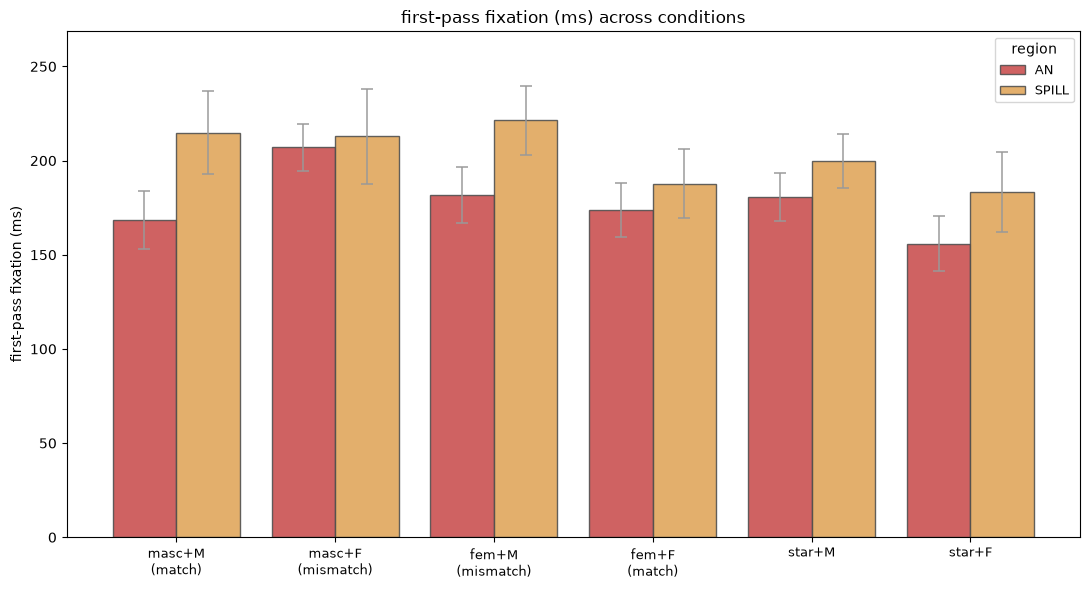

In [72]:
plot_measure(results, 'first_pass', regions=('AN', 'SPILL'))

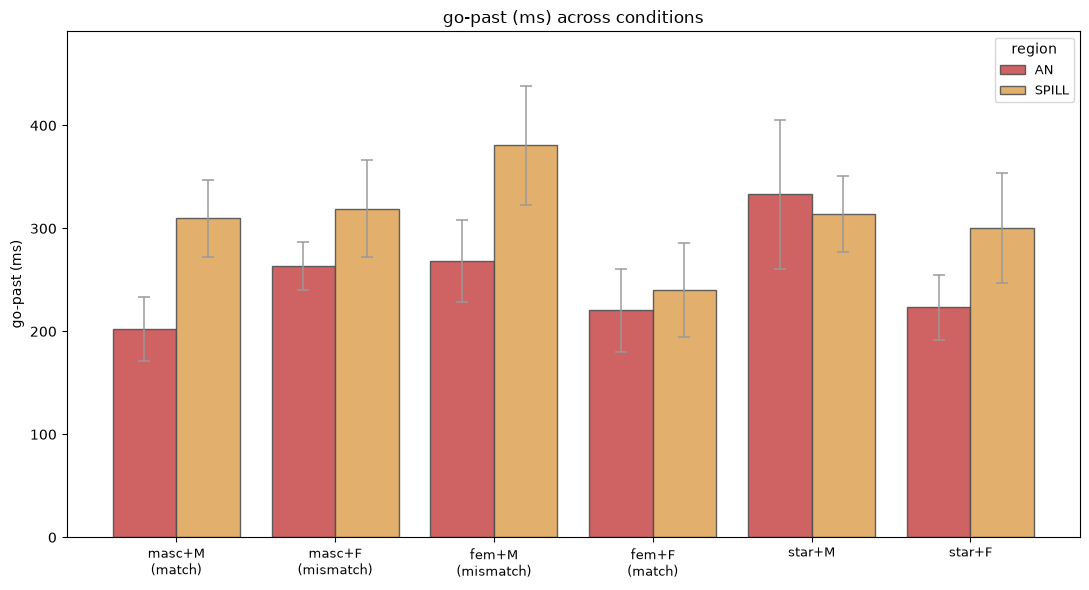

In [73]:
plot_measure(results, 'go_past', regions=('AN', 'SPILL'))

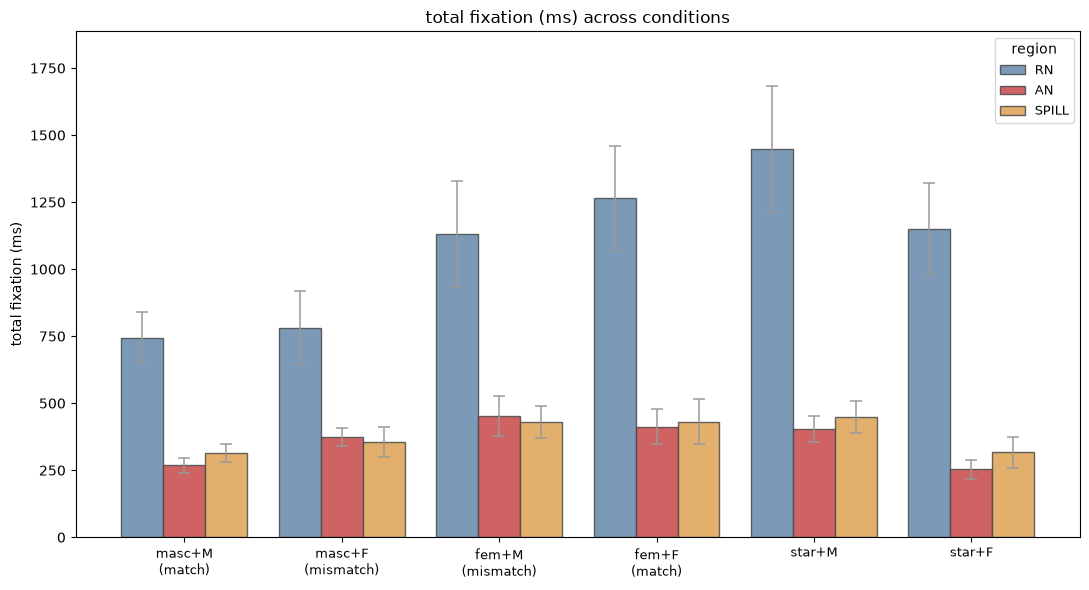

In [77]:
plot_measure(results, 'total', regions=('RN', 'AN', 'SPILL'))

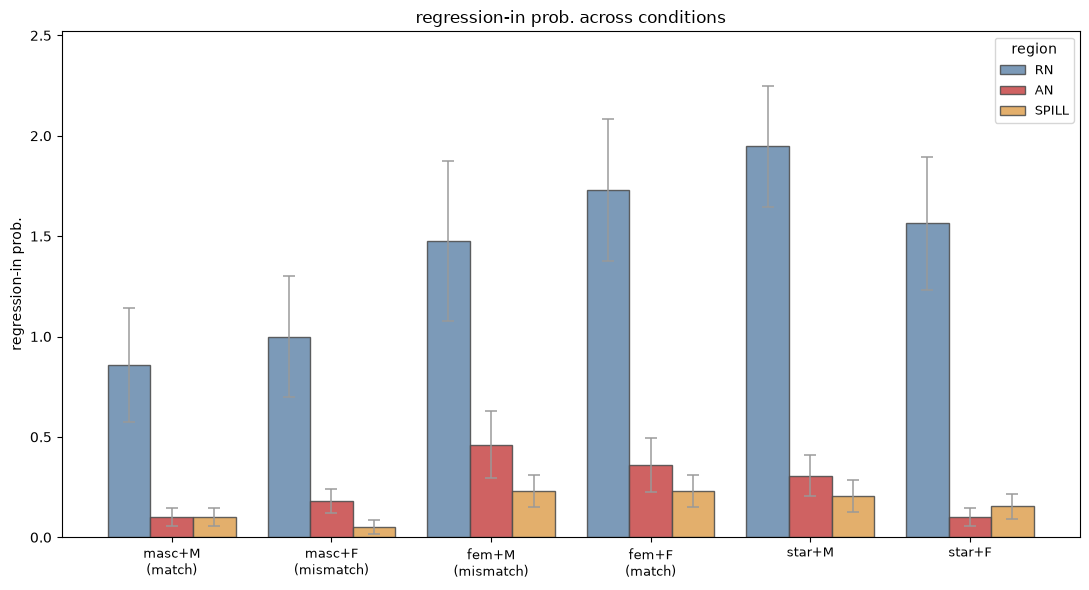

In [76]:
plot_measure(results, 'regression_in', regions=('RN', 'AN', 'SPILL'))